## Preamble

In [1]:
import os
import numpy as np
#from scipy import signal
import matplotlib.pyplot as plt

nz=201; nx=201; h=1.5

fpeak=7; dt=0.003; nt=1000

ntr=201

def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(ntr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

nzsnap=249; nxsnap=249; nsnap=51
def read_snap(filename,n=(nsnap,nxsnap,nzsnap),i=17):
    tmp=np.fromfile(filename,dtype='float32').reshape(n).T
    return tmp[:,:,i]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/GradientTest',setup='setup',np=1,nthreads=4,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

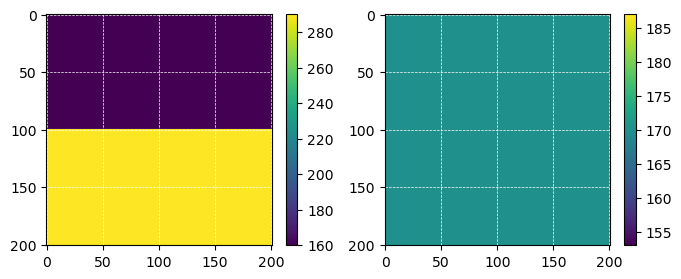

In [30]:
# True
!makevel nz=100 nx=$nx v000=160 > c1
!makevel nz=101 nx=$nx v000=290 > c2
!cat c1 c2 > tmp && transp < tmp n1=$nx > cel
!rm c1 c2 tmp
#density=0.4*np.pi
!makevel nz=$nz nx=$nx v000=1.25663708 > one
!cat cel one > true

# Background
!makevel nz=$nz nx=$nx v000=170 > cel
!cat cel one > init

#plot
plt.figure(figsize=(8,3))
true=read('true',(2*nx,nz))
init=read('init',(2*nx,nz))
plt.subplot(1,2,1); imshow(true[:,:nx])
plt.subplot(1,2,2); imshow(init[:,:nx])

In [47]:
#topo
!makevel nz=1   nx=$nx v000=78  > topo

In [44]:
%%writefile setup_default

MODEL_SIZE              '201 201 1'
MODEL_SPACING           '1.5 1.5 1'
FILE_MODEL               true
MODEL_ATTRIBUTES        'vp rho'
#FILE_TOPO               'topo'

IS_FREESURFACE          F

ACQUI_GEOMETRY          spread
FS                      '75 75  0'
FR                      '75  0  0'
DR                      '0  1.5 0'
NR                      201

SU_SCALCO   -10

SCOMP                   p
RCOMP                   p #'p vz'

WAVELET_TYPE            ricker
#T0                      0.5
#FILE_WAVELET            'fricker_dt6000.su'

IS_FREESURFACE  F

IF_HICKS        F
IF_BLOOM        F

IF_USE_RANDOM   F

NT           1000
DT           0.003
FPEAK        7

SNAPSHOT        'p vz vx'
#NSNAPSHOT    50


## for inversion ##
FILE_DATA_PREFIX    'results_obs/Ru_Shot'
WEIGHTING           'none'

PARAMETER           'vp:160:290'

SMOOTHING     'none'
#PRECO         'z^0'


#DESCENT_DIR     'random'  #'-curr%pg'

#LS_SCALING  'none'

JOB           'ls'

IF_USE_CHECKPOINT   F

Overwriting setup_default


## AC

### p-p

#### Obs & Syn data

In [33]:
!cp setup_default setup
!echo "DIR_OUT     results_obs" >> setup
run(app='/home/wzhou/SeisJIMU_AC/SeisJIMU/exe/FWD')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 wzhou wzhou 15 Jun 25 13:19 /home/wzhou/SeisJIMU_AC/SeisJIMU/exe/FWD -> fwd_AC_FDSG_O4_
 Git Commit: 3c77d52
 Git Branch: DAS
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/25/2026
System time: 13:42:41
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal

In [34]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "DIR_OUT     results_syn" >> setup
run(app='/home/wzhou/SeisJIMU_AC/SeisJIMU/exe/FWD')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 wzhou wzhou 15 Jun 25 13:19 /home/wzhou/SeisJIMU_AC/SeisJIMU/exe/FWD -> fwd_AC_FDSG_O4_
 Git Commit: 3c77d52
 Git Branch: DAS
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/25/2026
System time: 13:42:43
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_syn
 Output directory:results_syn/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal

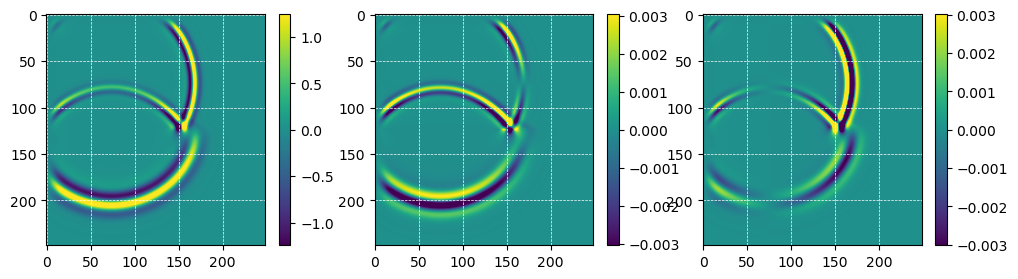

In [9]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('results_obs/snap_fld_u%p' ,(51,249,249)),perc=98)
plt.subplot(1,3,2); imshow(read_snap('results_obs/snap_fld_u%vz',(51,249,249)),perc=98)
plt.subplot(1,3,3); imshow(read_snap('results_obs/snap_fld_u%vx',(51,249,249)),perc=98)

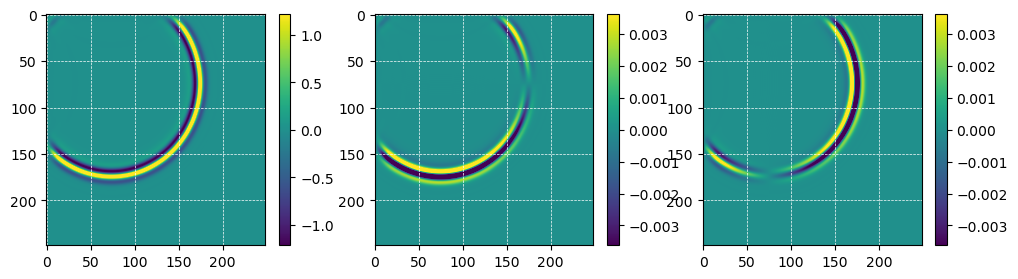

In [10]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('results_syn/snap_fld_u%p' ,(51,249,249)),perc=98)
plt.subplot(1,3,2); imshow(read_snap('results_syn/snap_fld_u%vz',(51,249,249)),perc=98)
plt.subplot(1,3,3); imshow(read_snap('results_syn/snap_fld_u%vx',(51,249,249)),perc=98)

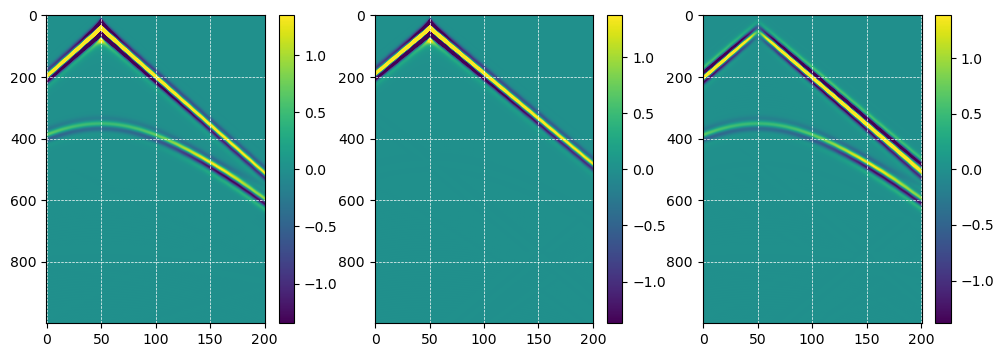

In [11]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); imshow(read_su('results_obs/Ru_Shot0001.su'),perc=98)
plt.subplot(1,3,2); imshow(read_su('results_syn/Ru_Shot0001.su'),perc=98)
plt.subplot(1,3,3); imshow(read_su('results_obs/Ru_Shot0001.su')-read_su('results_syn/Ru_Shot0001.su'),perc=98)

#### Gradient

In [40]:
!cp setup_default setup
!echo 'FILE_MODEL   init' >> setup
!echo "PARAMETER   'vp:160:290  rho:1.25663708:1.5'" >> setup

!echo "JOB   gradient" >> setup
run(app='/home/wzhou/SeisJIMU_AC/SeisJIMU/exe/fwi_AC_FDSG_O4_velocities-density_Wolfe_NLCG_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 962968 Jun 25 13:41 /home/wzhou/SeisJIMU_AC/SeisJIMU/exe/fwi_AC_FDSG_O4_velocities-density_Wolfe_NLCG_
 Git Commit: 3c77d52
 Git Branch: DAS
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/25/2026
System time: 13:43:34
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) 

 it----         500
 fld_a minmax values: -0.484715044      0.484715164    
 fld_u minmax values:  -6.78399159E-03   4.90190741E-03
 Elapsed time to load boundary               1.66190863E-02
 Elapsed time to update stresses            0.116837740    
 Elapsed time to rm source stresses          7.84397125E-04
 Elapsed time to update velocities          0.114851177    
 Elapsed time to rm source velocities        2.86996365E-04
 Total elapsed time for forward (min)   4.15632315E-03
  ---------------------------- 
 Elapsed time to add adjsource stresses      5.37979603E-03
 Elapsed time to update adj stresses        0.116563141    
 Elapsed time to add adjsource velocities    8.10110569E-03
 Elapsed time to update adj velocities      0.120626628    
 Elapsed time to extract&write fields        0.00000000    
 Elapsed time to correlate                   5.54549694E-03
 Total elapsed time for adjoint&correlate (min)   4.27026954E-03
 Total elapsed time (min):   8.42659269E-03
 Viewing the

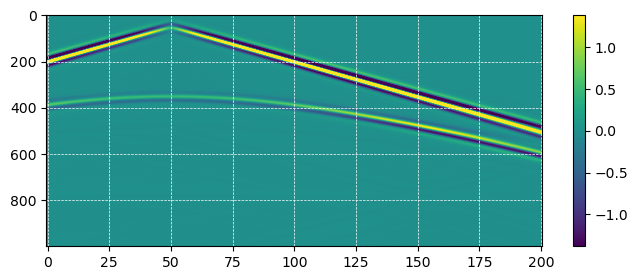

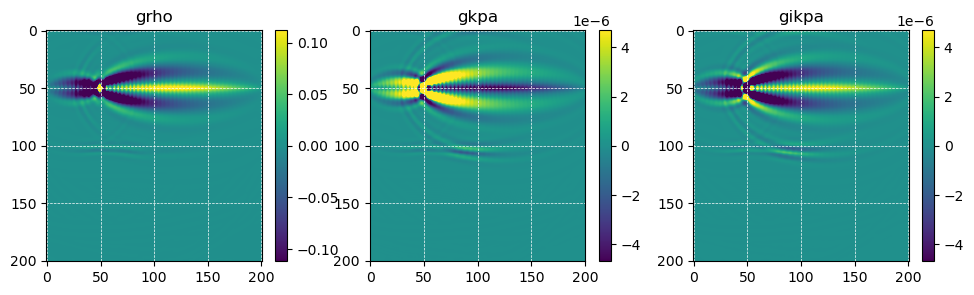

In [41]:
plt.figure(figsize=(8,3))
imshow(read_su('results/dadj_Shot0001.su'),perc=98)

corr=read('results/correlate_gradient',n=(2*nx,nz)) #grho gkpa
plt.figure(figsize=(16,3))
plt.subplot(1,4,1); imshow(corr[:,:nx],perc=98,title='grho')
plt.subplot(1,4,2); imshow(corr[:,nx:],perc=98,title='gkpa')
plt.subplot(1,4,3); imshow(-corr[:,nx:],perc=98,title='gikpa')

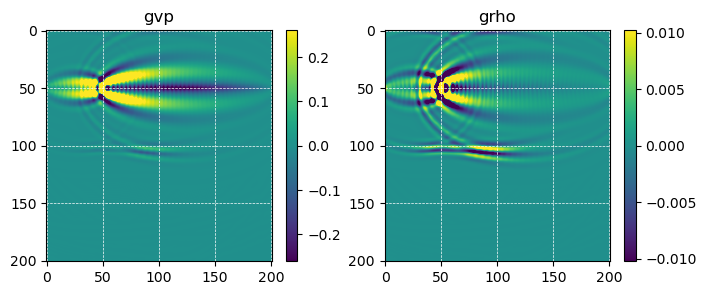

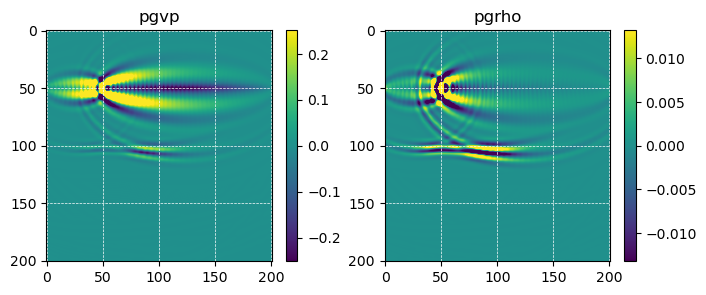

In [42]:
corr=read('results/qp0%g',(2*nx,nz))
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(corr[:,:nx],perc=98,title='gvp')
plt.subplot(1,2,2); imshow(corr[:,nx:],perc=98,title='grho')

corr=read('results/qp0%pg',(2*nx,nz))
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(corr[:,:nx],perc=98,title='pgvp')
plt.subplot(1,2,2); imshow(corr[:,nx:],perc=98,title='pgrho')

#### gradienttest_AC_FDSG_O4_velocities-density on gvp

In [45]:
!cp setup_default setup
!echo 'FILE_MODEL   init' >> setup
!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!/home/wzhou/SeisJIMU_AC/SeisJIMU/exe/gradienttest_AC_FDSG_O4_velocities-density  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   9.99999975E-06   10.9499540       10.9502678      -31.3758850      -32.0481758       1.02142704     T
 1st cond   9.99999975E-05   10.9472094       10.9502678      -30.5843353      -32.0481758       1.04786241     T
 1st cond   1.00000005E-03   10.9193554       10.9502678      -30.9123974      -32.0481758       1.03674185     T
 1st cond   9.99999978E-03   10.6445103       10.9502678      -30.5757523      -32.0481758       1.04815662     T
 1st cond  0.100000001       8.28432560       10.9502678      -26.6594219      -32.0481758       1.20213318     T
 1st cond   1.00000000       4.98375607       10.9502678      -5.96651173      -32.0481758       5.37134218     T


In [58]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
!/home/wzhou/SeisJIMU_AC/SeisJIMU/exe/gradienttest_AC_FDSG_O4_velocities-density  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond  -9.99999975E-06   10.9505882       10.9502678      -32.0434570      -32.0481758       1.00014722     F
 1st cond  -9.99999975E-05   10.9533768       10.9502678      -31.0897827      -32.0481758       1.03082657     F
 1st cond  -1.00000005E-03   10.9812937       10.9502678      -31.0258846      -32.0481758       1.03294957     F
 1st cond  -9.99999978E-03   11.2631292       10.9502678      -31.2861443      -32.0481758       1.02435684     F
 1st cond -0.100000001       14.3692827       10.9502678      -34.1901474      -32.0481758      0.937351227     F
 1st cond  -1.00000000       51.1952324       10.9502678      -40.2449646      -32.0481758      0.796327591     F


#### gradienttest_AC_FDSG_O4_velocities-density on grho

In [48]:
!cp setup_default setup
!echo 'FILE_MODEL   init' >> setup
!echo 'FILE_TOPO    topo' >> setup

!echo "PARAMETER   'rho:1.25663708:2' " >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!/home/wzhou/SeisJIMU_AC/SeisJIMU/exe/gradienttest_AC_FDSG_O4_velocities-density  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   9.99999975E-06   25245.4375       25255.2676      -983007.812      -2716377.25       2.76333237     T
 1st cond   9.99999975E-05   25157.6836       25255.2676      -975839.875      -2716377.25       2.78363013     T
 1st cond   1.00000005E-03   24369.3047       25255.2676      -885962.875      -2716377.25       3.06601691     T
 1st cond   9.99999978E-03   21260.8359       25255.2676      -399443.188      -2716377.25       6.80040932     T
 1st cond  0.100000001       20376.8086       25255.2676      -48784.5898      -2716377.25       55.6810532     T
 1st cond   1.00000000       22071.4023       25255.2676      -3183.86523      -2716377.25       853.169678     T


In [50]:
!cp setup_default setup
!echo 'FILE_MODEL   init' >> setup
# !echo 'FILE_TOPO    topo' >> setup

!echo "PARAMETER   'rho:0.6:2.5' " >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!/home/wzhou/SeisJIMU_AC/SeisJIMU/exe/gradienttest_AC_FDSG_O4_velocities-density  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   9.99999975E-06   1637.47058       1643.22498      -575439.438      -623071.000       1.08277428     T
 1st cond   9.99999975E-05   1587.37012       1643.22498      -558548.625      -623071.000       1.11551797     T
 1st cond   1.00000005E-03   1267.87146       1643.22498      -375353.500      -623071.000       1.65995789     T
 1st cond   9.99999978E-03   2272.39551       1643.22498       62917.0547      -623071.000      -9.90305424     F
 1st cond  0.100000001       4203.29492       1643.22498       25600.6973      -623071.000      -24.3380489     F
 1st cond   1.00000000       4820.08545       1643.22498       3176.86035      -623071.000      -196.127914     F
